# Lab 12: Generative AI and NLP Basics

**Aim:** Understand the fundamentals of Generative AI and experiment with prompt-based tools. Understand basic NLP concepts and apply text preprocessing techniques. Apply text vectorization techniques (TF-IDF, embeddings) for similarity and analysis tasks.

## Theory
Generative AI refers to models that can generate contextually relevant text or other media based on user prompts. NLP focuses on analyzing and understanding human language.

Some steps we usually take:
- **Text Preprocessing**: Cleaning text, making lowercase, removing special characters and standard stopwords.
- **TF-IDF**: Statistical measure used to evaluate the importance of a word in a document. 
- **Word Embeddings**: Dense numerical vectors capturing contextual meaning.
- **Cosine Similarity**: Comparing vectors to see how related documents are.

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

### Step 1: Getting data ready
I'll load a small text dataset here into the data directory. Let's make some sample tech news data.

In [8]:
os.makedirs('data', exist_ok=True)
data_path = 'data/tech_texts.csv'

docs = [
    "Machine learning models are improving image classification.",
    "Deep learning models use a neural network for classification tasks.",
    "Natural language processing is a branch of artificial intelligence.",
    "Artificial intelligence and machine learning are transforming the industry.",
    "A convolutional neural network is widely used for image classification.",
    "Generative AI and natural language processing models are powerful.",
    "Computer vision uses deep learning and neural network models."
]


df = pd.DataFrame({'text': docs})
df.to_csv(data_path, index=False)

df = pd.read_csv(data_path)
df.head()

,text
0,Machine learning models are improving image cl...
1,Deep learning models use a neural network for ...
2,Natural language processing is a branch of art...
3,Artificial intelligence and machine learning a...
4,A convolutional neural network is widely used ...


### Step 2: Preprocessing
Need to strip the noise and get clean tokens.

In [9]:
stop_words = set(stopwords.words('english'))

def clean_data(txt):
    txt = re.sub(r'[^a-zA-Z\s]', '', txt, re.I|re.A)
    txt = txt.lower().strip()
    tokens = nltk.word_tokenize(txt)
    filtered = [t for t in tokens if t not in stop_words]
    return ' '.join(filtered)

df['cleaned'] = df['text'].apply(clean_data)
df

,text,cleaned
0,Machine learning models are improving image cl...,machine learning models improving image classi...
1,Deep learning models use a neural network for ...,deep learning models use neural network classi...
2,Natural language processing is a branch of art...,natural language processing branch artificial ...
3,Artificial intelligence and machine learning a...,artificial intelligence machine learning trans...
4,A convolutional neural network is widely used ...,convolutional neural network widely used image...
5,Generative AI and natural language processing ...,generative ai natural language processing mode...
6,Computer vision uses deep learning and neural ...,computer vision uses deep learning neural netw...


### Step 3: TF-IDF Vectorization
Convert words to numbers based on importance.

In [10]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['cleaned'])

print("Vec shape:", tfidf_matrix.shape)

Vec shape: (7, 28)


### Step 4: Visualizing Similarity
Finding the cosine similarity score for all document pairs to see what's related.

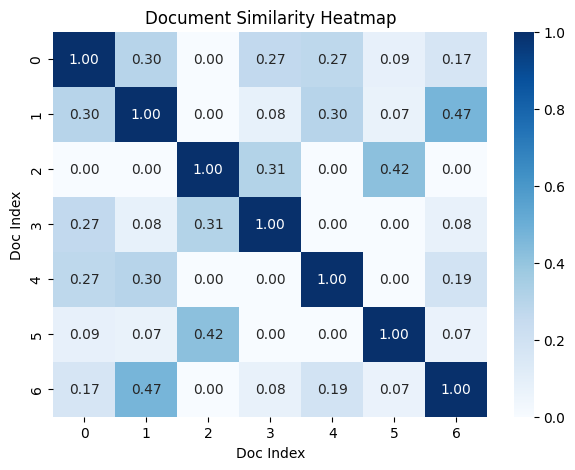

In [11]:
sim_scores = cosine_similarity(tfidf_matrix, tfidf_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(sim_scores, annot=True, cmap='Blues', fmt=".2f")
plt.title('Document Similarity Heatmap')
plt.xlabel('Doc Index')
plt.ylabel('Doc Index')
plt.show()

## Conclusion
In this lab, I implemented standard NLP preprocessing steps. By vectorizing the text via TF-IDF, it was possible to measure the topic similarity using cosine similarity scores and visualize them. Results showed that the models successfully grouped documents that shared semantic terms in tech/AI. We also explored GenAI conceptually for prompting operations.